# Análisis Exploratorio de Datos (EDA) - Autos Usados

Este notebook contiene el análisis exploratorio inicial del dataset `used_cars_dataset_v2.csv`. El objetivo es entender la distribución de los datos, limpiar los valores nulos o con formatos incorrectos (como precios en rupias y textos en kilometraje), y preparar el dataset para el dashboard final.

## 1. Descarga y Carga de Datos

Descargamos el dataset usando `kagglehub` y lo copiamos a la carpeta `../data/`.

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import shutil
import os

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Descargar dataset de Kaggle
path = kagglehub.dataset_download('mohitkumar282/used-car-dataset')
src = os.path.join(path, 'used_cars_dataset_v2.csv')

# Crear directorio si no existe y copiar
os.makedirs('../data', exist_ok=True)
dst = '../data/used_cars_dataset_v2.csv'
shutil.copy(src, dst)
print("Dataset descargado y movido a:", dst)

# Cargar dataset
df = pd.read_csv(dst)
display(df.head())

Dataset descargado y movido a: ../data/used_cars_dataset_v2.csv


,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,Honda,City,2001,23,"98,000 km",Manual,second,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...","₹ 1,95,000"
1,Toyota,Innova,2009,15,190000.0 km,Manual,second,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...","₹ 3,75,000"
2,Volkswagen,VentoTest,2010,14,"77,246 km",Manual,first,Diesel,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...","₹ 1,84,999"
3,Maruti Suzuki,Swift,2017,7,"83,500 km",Manual,second,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,"₹ 5,65,000"
4,Maruti Suzuki,Baleno,2019,5,"45,000 km",Automatic,first,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","₹ 6,85,000"


In [42]:
# Información general del dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14993 entries, 0 to 14992
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Brand         14993 non-null  str  
 1   model         14993 non-null  str  
 2   Year          14993 non-null  int64
 3   Age           14993 non-null  int64
 4   kmDriven      14905 non-null  str  
 5   Transmission  14993 non-null  str  
 6   Owner         14993 non-null  str  
 7   FuelType      14993 non-null  str  
 8   PostedDate    14993 non-null  str  
 9   AdditionInfo  14993 non-null  str  
 10  AskPrice      14993 non-null  str  
dtypes: int64(2), str(9)
memory usage: 2.8 MB


## 2. Limpieza de Datos

El dataset presenta columnas numéricas clave que están en formato de texto (`kmDriven` y `AskPrice`).

- `kmDriven`: Contiene el texto ' km' y comas.
- `AskPrice`: Contiene el símbolo de la Rupia India (₹) y comas.

Procederemos a:
1. Normalizar los nombres de todas las columnas a **minúsculas**.
2. Limpiar e interpretar las columnas como valores numéricos.
3. **Transformar el precio directamente a Pesos Chilenos (CLP)** utilizando una tasa de conversión aproximada (1 INR = 11 CLP), asumiendo este precio como el valor de lista definitivo en la columna `askprice`.

In [43]:
# Normalizar nombres de columnas a minúsculas
df.columns = df.columns.str.lower()

# Limpiar kmdriven
# Eliminar ' km', eliminar comas, y convertir a float
df['kmdriven'] = df['kmdriven'].str.replace(' km', '', regex=False).str.replace(',', '', regex=False)
df['kmdriven'] = pd.to_numeric(df['kmdriven'], errors='coerce')

# Limpiar askprice
# Eliminar el símbolo de la rupia (₹), comas, convertir a float y pasar a CLP (* 11)
df['askprice'] = df['askprice'].str.replace('₹', '', regex=False).str.replace(',', '', regex=False)
df['askprice'] = pd.to_numeric(df['askprice'], errors='coerce') * 11.0

# Eliminar filas con nulos en estas columnas críticas
df = df.dropna(subset=['kmdriven', 'askprice'])

display(df[['brand', 'model', 'kmdriven', 'askprice']].head())

,brand,model,kmdriven,askprice
0,Honda,City,98000.0,2145000.0
1,Toyota,Innova,190000.0,4125000.0
2,Volkswagen,VentoTest,77246.0,2034989.0
3,Maruti Suzuki,Swift,83500.0,6215000.0
4,Maruti Suzuki,Baleno,45000.0,7535000.0


Guardamos el dataset limpio para que pueda ser consumido rápidamente por nuestra aplicación de Streamlit (`app.py`).

In [44]:
# Guardar dataset limpio
df.to_csv('../data/used_cars_dataset_v2_clean.csv', index=False)
print("Dataset limpio guardado en '../data/used_cars_dataset_v2_clean.csv'")

Dataset limpio guardado en '../data/used_cars_dataset_v2_clean.csv'


## 3. Análisis Exploratorio (Visualizaciones)

### 3.1 Distribución del Precio de Reventa en CLP
Veamos cómo se distribuyen los precios de los autos usados.

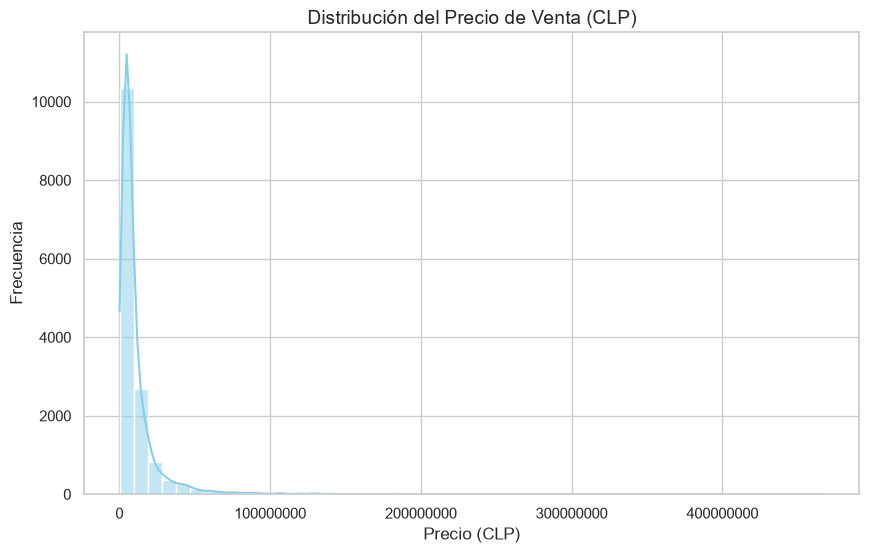

In [45]:
plt.figure(figsize=(10, 6))
sns.histplot(df['askprice'], bins=50, kde=True, color='skyblue')
plt.title('Distribución del Precio de Venta (CLP)', fontsize=14)
plt.xlabel('Precio (CLP)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)

# Ajustar formato del eje X para que no se vea en notación científica
plt.ticklabel_format(style='plain', axis='x')
plt.show()

### 3.2 Impacto del Kilometraje en el Precio
La teoría sugiere que a mayor kilometraje, el precio debería ser menor (depreciación).

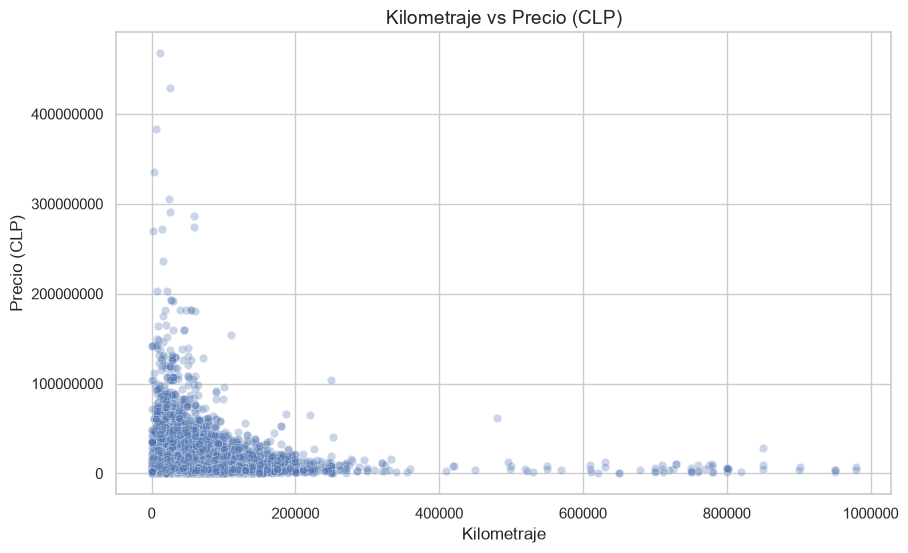

In [46]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='kmdriven', y='askprice', alpha=0.3)
plt.title('Kilometraje vs Precio (CLP)', fontsize=14)
plt.xlabel('Kilometraje', fontsize=12)
plt.ylabel('Precio (CLP)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

### 3.3 Impacto de la Transmisión en el Precio
¿Los autos automáticos mantienen mejor su valor que los manuales?

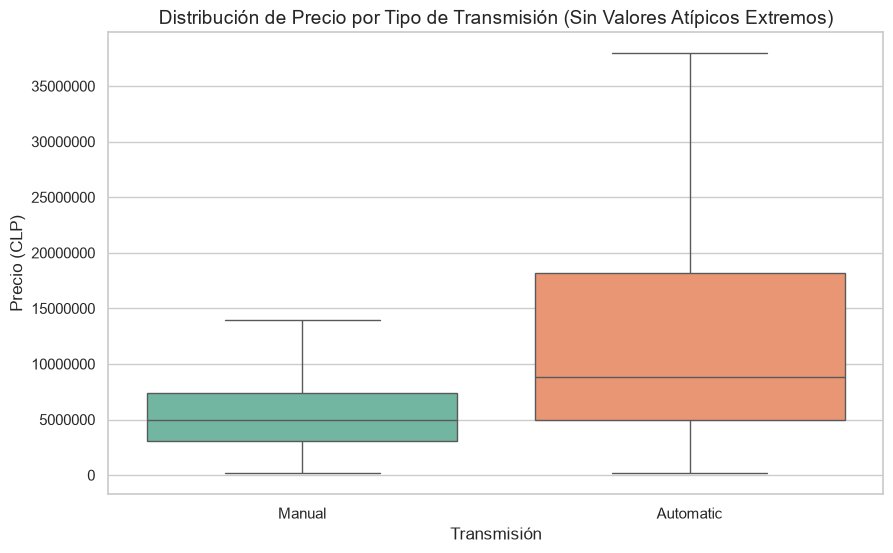

In [47]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='transmission', y='askprice', hue='transmission', palette='Set2', legend=False, showfliers=False)
plt.title('Distribución de Precio por Tipo de Transmisión (Sin Valores Atípicos Extremos)', fontsize=14)
plt.xlabel('Transmisión', fontsize=12)
plt.ylabel('Precio (CLP)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

### 3.4 Autos en Venta por Año y Marca
Analicemos el volumen de autos disponibles según su año de fabricación y las marcas más populares en el mercado.

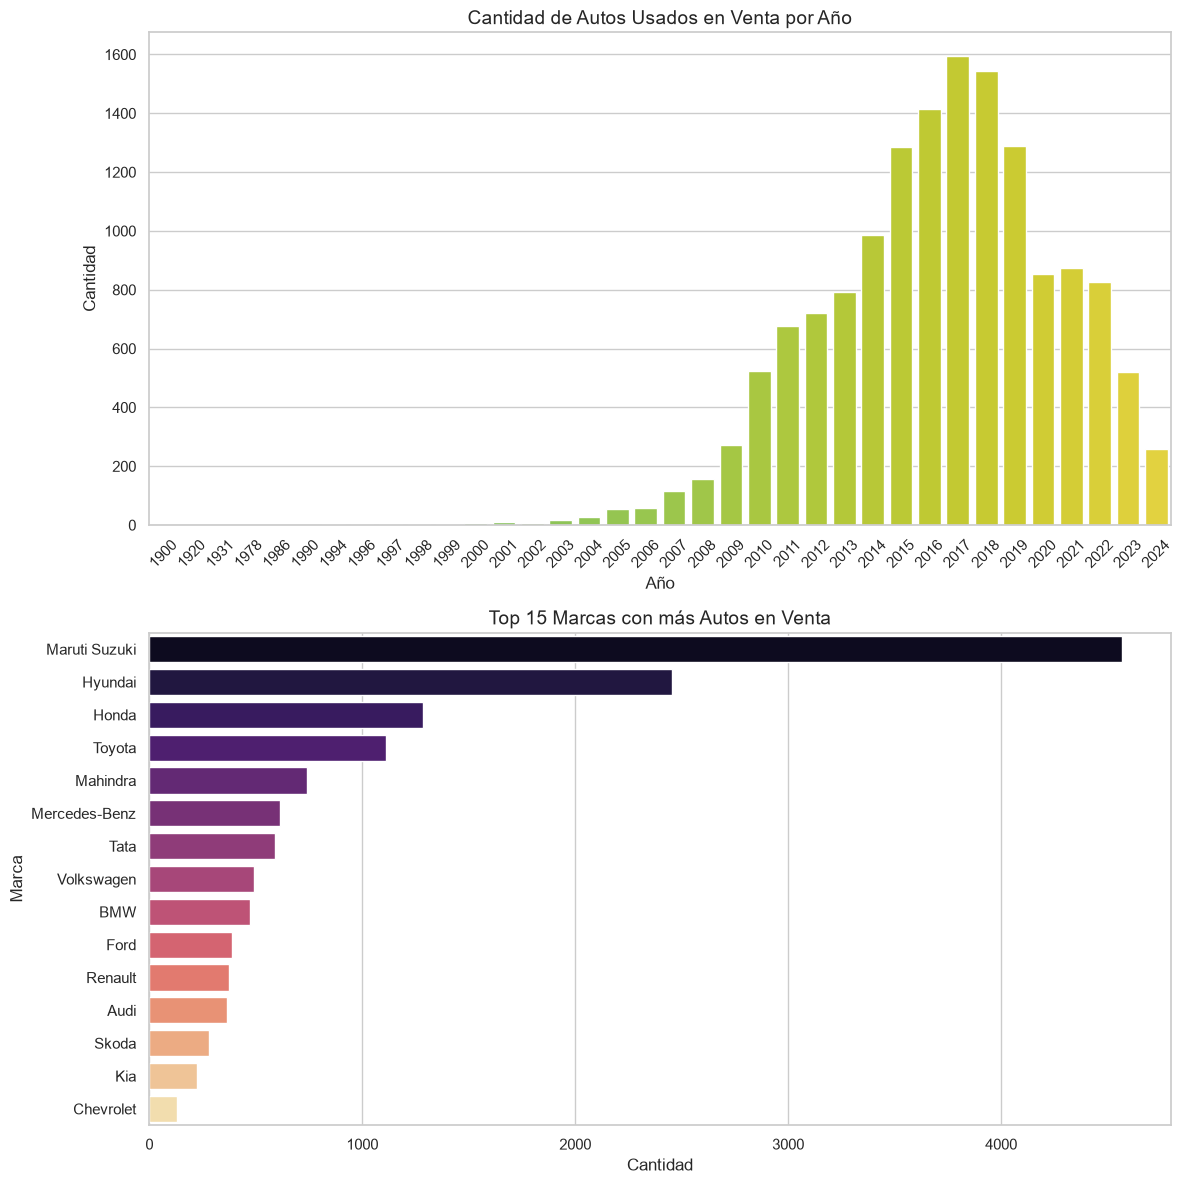

In [48]:
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# Autos por Año
sns.countplot(data=df, x='year', hue='year', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Cantidad de Autos Usados en Venta por Año', fontsize=14)
axes[0].set_xlabel('Año', fontsize=12)
axes[0].set_ylabel('Cantidad', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Autos por Marca (Top 15)
top_marcas = df['brand'].value_counts().head(15)
sns.barplot(x=top_marcas.values, y=top_marcas.index, hue=top_marcas.index, palette='magma', legend=False, ax=axes[1])
axes[1].set_title('Top 15 Marcas con más Autos en Venta', fontsize=14)
axes[1].set_xlabel('Cantidad', fontsize=12)
axes[1].set_ylabel('Marca', fontsize=12)

plt.tight_layout()
plt.show()

## 4. Pregunta de Análisis Formulada

> **¿Cómo impactan el kilometraje, la edad del auto y la transmisión en el valor de reventa en el mercado de vehículos usados?**

Esta pregunta guiará la construcción de nuestro dashboard en Streamlit, donde permitiremos a los usuarios explorar estas variables y estimar el valor de mercado de un vehículo.